In [1]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import nibabel as nib

from PIL import Image
from skimage.transform import resize

from sklearn.model_selection import train_test_split

In [8]:
import os

DATASET_ROOT = "/home/nyxelray/Pythonstuff/Swin/dataset"

for root, dirs, files in os.walk(DATASET_ROOT):
    for file in files:
        if file.endswith(".xlsx"):
            print(os.path.join(root, file))

/home/nyxelray/Pythonstuff/Swin/dataset/Center1/Center1_label.xlsx
/home/nyxelray/Pythonstuff/Swin/dataset/Center2/Center2_label.xlsx
/home/nyxelray/Pythonstuff/Swin/dataset/Center3/Center3_label.xlsx
/home/nyxelray/Pythonstuff/Swin/dataset/Center4/Center4_label.xlsx


In [9]:
import os

print(os.listdir("/home/nyxelray/Pythonstuff/Swin/dataset"))

['Center1', 'Center2', 'Center3', 'Center4']


In [11]:
import pandas as pd

all_labels = []

for center in ["Center1", "Center2", "Center3", "Center4"]:

    path = f"/home/nyxelray/Pythonstuff/Swin/dataset/{center}/{center}_label.xlsx"

    df = pd.read_excel(path)

    df["center"] = center

    all_labels.append(df)

labels_df = pd.concat(all_labels, ignore_index=True)

print("Total samples:", len(labels_df))
print("\nClass distribution:")
print(labels_df["label"].value_counts())

labels_df.head()

Total samples: 275

Class distribution:
label
0    190
1     85
Name: count, dtype: int64


,mask_name,label,image,mask_new,Age (years),Gender,Pathological T stage,Pathological grade,Type of patient's tumor number,center,image_name
0,1,0,001.nii.gz,001.nii.gz,67,Male,Ta,Low,Single,Center1,NaN
1,2,0,002.nii.gz,002.nii.gz,58,Male,Ta,Low,Single,Center1,NaN
2,3,0,003.nii.gz,003.nii.gz,75,Male,Ta,Low,Single,Center1,NaN
3,4,0,004.nii.gz,004.nii.gz,77,Male,Ta,High,Single,Center1,NaN
4,5,1,005.nii.gz,005.nii.gz,67,Male,T2,High,Single,Center1,NaN


In [12]:
labels_df["case_id"] = (
    labels_df["image"]
    .str.replace(".nii.gz", "", regex=False)
    .apply(lambda x: f"case_{x}")
)

labels_df[["image", "case_id"]].head()

,image,case_id
0,001.nii.gz,case_001
1,002.nii.gz,case_002
2,003.nii.gz,case_003
3,004.nii.gz,case_004
4,005.nii.gz,case_005


In [13]:
import os

IMAGE_DIR = "/home/nyxelray/Pythonstuff/Swin/nnUNet_raw/Dataset001_Bladder/imagesTr"
MASK_DIR = "/home/nyxelray/Pythonstuff/Swin/nnUNet_raw/Dataset001_Bladder/labelsTr"

valid_cases = []

for case_id in labels_df["case_id"]:

    image_path = os.path.join(
        IMAGE_DIR,
        f"{case_id}_0000.nii.gz"
    )

    mask_path = os.path.join(
        MASK_DIR,
        f"{case_id}.nii.gz"
    )

    if os.path.exists(image_path) and os.path.exists(mask_path):
        valid_cases.append(case_id)

print("Valid cases:", len(valid_cases))
print("Missing cases:", len(labels_df) - len(valid_cases))

Valid cases: 160
Missing cases: 115


In [14]:
import os

for center in ["Center1","Center2","Center3","Center4"]:
    center_path = f"/home/nyxelray/Pythonstuff/Swin/dataset/{center}"

    print(f"\n{center}")

    for item in os.listdir(center_path):
        print("  ", item)


Center1
   Annotation
   Center1_label.xlsx
   T2WI

Center2
   Annotation
   Center2_label.xlsx
   T2WI

Center3
   Annotation
   Center3_label.xlsx
   T2WI

Center4
   Annotation
   Center4_label.xlsx
   T2WI


In [15]:
for center in ["Center1","Center2","Center3","Center4"]:

    df = pd.read_excel(
        f"/home/nyxelray/Pythonstuff/Swin/dataset/{center}/{center}_label.xlsx"
    )

    print(center, len(df))

Center1 160
Center2 48
Center3 32
Center4 35


In [16]:
import os

images = [
    f for f in os.listdir(
        "/home/nyxelray/Pythonstuff/Swin/nnUNet_raw/Dataset001_Bladder/imagesTr"
    )
    if f.endswith(".nii.gz")
]

print(len(images))

275


In [18]:
import os

for center in ["Center2", "Center3", "Center4"]:

    t2_path = f"/home/nyxelray/Pythonstuff/Swin/dataset/{center}/T2WI"
    ann_path = f"/home/nyxelray/Pythonstuff/Swin/dataset/{center}/Annotation"

    print(f"\n{center}")
    print("MRI files :", len(os.listdir(t2_path)))
    print("Masks     :", len(os.listdir(ann_path)))

    print("Example MRI :", sorted(os.listdir(t2_path))[:5])
    print("Example Mask:", sorted(os.listdir(ann_path))[:5])


Center2
MRI files : 47
Masks     : 48
Example MRI : ['01.nii.gz', '02.nii.gz', '03.nii.gz', '04.nii.gz', '05.nii.gz']
Example Mask: ['01.nii.gz', '02.nii.gz', '03.nii.gz', '04.nii.gz', '05.nii.gz']

Center3
MRI files : 24
Masks     : 32
Example MRI : ['01.nii.gz', '02.nii.gz', '03.nii.gz', '04.nii.gz', '05.nii.gz']
Example Mask: ['01.nii.gz', '02.nii.gz', '03.nii.gz', '04.nii.gz', '05.nii.gz']

Center4
MRI files : 31
Masks     : 35
Example MRI : ['01.nii.gz', '02.nii.gz', '03.nii.gz', '04.nii.gz', '05.nii.gz']
Example Mask: ['01.nii.gz', '02.nii.gz', '03.nii.gz', '04.nii.gz', '05_1.nii.gz']


In [19]:
import os

for center in ["Center2", "Center3", "Center4"]:

    t2_path = f"/home/nyxelray/Pythonstuff/Swin/dataset/{center}/T2WI"
    ann_path = f"/home/nyxelray/Pythonstuff/Swin/dataset/{center}/Annotation"

    mri = set(os.listdir(t2_path))
    masks = set(os.listdir(ann_path))

    print(f"\n{center}")

    print("Masks without MRI:")
    print(sorted(masks - mri))

    print("\nMRI without mask:")
    print(sorted(mri - masks))


Center2
Masks without MRI:
['13_1.nii.gz', '13_2.nii.gz']

MRI without mask:
['13.nii.gz']

Center3
Masks without MRI:
['09_1.nii.gz', '09_2.nii.gz', '12_1.nii.gz', '12_2.nii.gz', '12_3.nii.gz', '16_1.nii.gz', '16_2.nii.gz', '16_3.nii.gz', '16_4.nii.gz', '17_1.nii.gz', '17_2.nii.gz', '22_1.nii.gz', '22_2.nii.gz']

MRI without mask:
['09.nii.gz', '12.nii.gz', '16.nii.gz', '17.nii.gz', '22.nii.gz']

Center4
Masks without MRI:
['05_1.nii.gz', '05_2.nii.gz', '07_1.nii.gz', '07_2.nii.gz', '07_3.nii.gz', '08_1.nii.gz', '08_2.nii.gz']

MRI without mask:
['05.nii.gz', '07.nii.gz', '08.nii.gz']


In [20]:
import os
import shutil
from sklearn.model_selection import train_test_split

SOURCE_DIR = "/home/nyxelray/Pythonstuff/Swin/efficientnet_dataset"
OUTPUT_DIR = "/home/nyxelray/Pythonstuff/Swin/effnet_split"

os.makedirs(OUTPUT_DIR, exist_ok=True)

files = []
labels = []

for label in ["0", "1"]:
    class_dir = os.path.join(SOURCE_DIR, label)

    for fname in os.listdir(class_dir):
        if fname.endswith(".png"):
            files.append(os.path.join(class_dir, fname))
            labels.append(label)

# train = 70%, temp = 30%
train_files, temp_files, train_labels, temp_labels = train_test_split(
    files,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# val = 15%, test = 15%
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

splits = {
    "train": (train_files, train_labels),
    "val": (val_files, val_labels),
    "test": (test_files, test_labels)
}

for split_name, (split_files, split_labels) in splits.items():

    for fpath, label in zip(split_files, split_labels):

        dst_dir = os.path.join(
            OUTPUT_DIR,
            split_name,
            label
        )

        os.makedirs(dst_dir, exist_ok=True)

        shutil.copy(
            fpath,
            os.path.join(
                dst_dir,
                os.path.basename(fpath)
            )
        )

print("Dataset split complete.")

Dataset split complete.


In [21]:
import os

ROOT = "/home/nyxelray/Pythonstuff/Swin/effnet_split"

for split in ["train", "val", "test"]:

    print(f"\n{split}")

    for label in ["0", "1"]:

        path = os.path.join(ROOT, split, label)

        count = len(os.listdir(path))

        print(label, count)


train
0 64
1 21

val
0 14
1 4

test
0 14
1 5


In [22]:
import torch

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_dataset = ImageFolder(
    "/home/nyxelray/Pythonstuff/Swin/effnet_split/train",
    transform=train_transform
)

val_dataset = ImageFolder(
    "/home/nyxelray/Pythonstuff/Swin/effnet_split/val",
    transform=val_transform
)

test_dataset = ImageFolder(
    "/home/nyxelray/Pythonstuff/Swin/effnet_split/test",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 85
Val: 18
Test: 19


In [23]:
import torch
import torch.nn as nn

from torchvision.models import efficientnet_b0

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = efficientnet_b0(weights="DEFAULT")

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/nyxelray/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 17.9MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [24]:
weights = torch.tensor(
    [0.61, 2.67],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [26]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100*correct/total:.2f}%"
        )

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [27]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return (
        epoch_loss,
        epoch_acc,
        all_labels,
        all_preds
    )


In [29]:
best_val_acc = 0
NUM_EPOCHS = 20
train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_effnet_b0.pth"
        )

        print("Best model saved.")

print("\nTraining complete.")


Epoch 1/20


100%|██████████| 6/6 [00:00<00:00, 10.02it/s, acc=78.82%, loss=0.4528]


Train Loss: 0.4233 | Train Acc: 78.82%
Val Loss: 0.7561 | Val Acc: 61.11%
Best model saved.

Epoch 2/20


100%|██████████| 6/6 [00:00<00:00,  7.78it/s, acc=78.82%, loss=0.3396]


Train Loss: 0.4283 | Train Acc: 78.82%
Val Loss: 0.7831 | Val Acc: 66.67%
Best model saved.

Epoch 3/20


...

Train Loss: 0.1559 | Train Acc: 94.12%
Val Loss: 0.9082 | Val Acc: 72.22%

Epoch 19/20


100%|██████████| 6/6 [00:00<00:00, 11.30it/s, acc=94.12%, loss=0.3141]


Train Loss: 0.1643 | Train Acc: 94.12%
Val Loss: 0.9034 | Val Acc: 66.67%

Epoch 20/20


100%|██████████| 6/6 [00:00<00:00,  8.39it/s, acc=95.29%, loss=0.0412] 


Train Loss: 0.1239 | Train Acc: 95.29%
Val Loss: 1.1563 | Val Acc: 72.22%

Training complete.


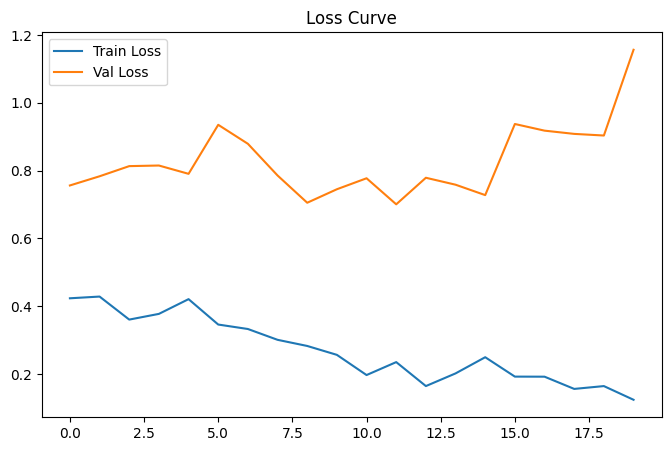

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

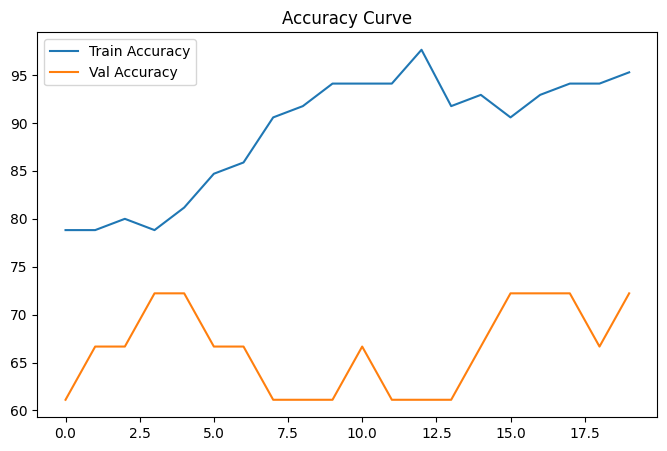

In [31]:
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [32]:
model.load_state_dict(
    torch.load(
        "best_effnet_b0.pth",
        map_location=device
    )
)

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [33]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

test_loss, test_acc, y_true, y_pred = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f"\nTest Accuracy: {test_acc:.2f}%")

print(
    classification_report(
        y_true,
        y_pred
    )
)


Test Accuracy: 63.16%
              precision    recall  f1-score   support

           0       0.82      0.64      0.72        14
           1       0.38      0.60      0.46         5

    accuracy                           0.63        19
   macro avg       0.60      0.62      0.59        19
weighted avg       0.70      0.63      0.65        19



In [34]:
from sklearn.metrics import roc_auc_score
import numpy as np

model.eval()

probs = []
labels_all = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        prob = torch.softmax(
            outputs,
            dim=1
        )[:,1]

        probs.extend(
            prob.cpu().numpy()
        )

        labels_all.extend(
            labels.numpy()
        )

auc = roc_auc_score(
    labels_all,
    probs
)

print("ROC-AUC:", auc)

ROC-AUC: 0.6142857142857143


In [37]:
import json

summary_path = "/home/nyxelray/Pythonstuff/Swin/nnUNet_results/Dataset001_Bladder/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/summary.json"

with open(summary_path, "r") as f:
    summary = json.load(f)

mean_dice = summary["foreground_mean"]["Dice"]
mean_iou = summary["foreground_mean"]["IoU"]

best_case = max(
    summary["metric_per_case"],
    key=lambda x: x["metrics"]["1"]["Dice"]
)

best_dice = best_case["metrics"]["1"]["Dice"]

print(f"Mean Dice : {mean_dice:.4f}")
print(f"Mean IoU  : {mean_iou:.4f}")
print(f"Best Dice : {best_dice:.4f}")
print(f"Best Case : {best_case['prediction_file'].split('/')[-1]}")

Mean Dice : 0.5292
Mean IoU  : 0.4486
Best Dice : 0.9324
Best Case : case_036.nii.gz
